# 📊 VN30 Market Analysis — 2020 → Today
**Data Analyst Portfolio Project | vnstock · Python · Power BI**

---
Phân tích VN30 qua **5 giai đoạn lịch sử**:

| Giai đoạn | Thời gian | Đặc trưng |
|-----------|-----------|----------|
| COVID Crash | T1–T3/2020 | VN-Index -35% trong 7 tuần |
| COVID Recovery | T4/2020–2021 | Bật phục +90%, thanh khoản kỷ lục |
| TPDN Crisis | 2022 | VN-Index mất 32.8%, khủng hoảng TPDN |
| Phục hồi & Rebound | 2023–2024 | Giảm lãi suất 4 lần, thị trường tái thiết |
| YTD 2025 | 2025→hôm nay | Kỳ vọng nâng hạng FTSE Emerging Markets |

**Workflow:**
```
[1] vn30_analysis.ipynb   → tạo output/*.csv (lần đầu, full history)
[2] Power BI Desktop       → import CSV, xây dashboard
[3] update_data.py         → append dữ liệu mới → Power BI Refresh
```

## 0 · Setup & Config

In [1]:
# !pip install -U vnstock pandas numpy matplotlib seaborn

import time, os, warnings
from datetime import datetime, date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from vnstock import Listing, Quote, Trading

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

START  = '2020-01-01'
END    = date.today().strftime('%Y-%m-%d')   # luôn lấy đến hôm nay
SOURCE = 'KBS'
BATCH  = 20       # Guest: 20 req/phút | Community: 60
DELAY  = 62       # giây nghỉ sau mỗi batch
DATA    = 'data'
os.makedirs(DATA, exist_ok=True)
ASSET    = 'assets'
os.makedirs(ASSET, exist_ok=True)

print(f'✅ Ready | {START} → {END} (YTD auto)')
print(f'   {BATCH} req/batch | delay {DELAY}s | source={SOURCE}')

✅ Ready | 2020-01-01 → 2026-04-08 (YTD auto)
   20 req/batch | delay 62s | source=KBS


In [2]:
# ── Định nghĩa giai đoạn & sự kiện — dùng trong tất cả chart ────

PHASE_COLORS = {
    '1_COVID_Crash':    ('#FFCDD2', 'COVID Crash'),
    '2_COVID_Recovery': ('#C8E6C9', 'COVID Recovery'),
    '3_TPDN_Crisis':    ('#FFCCBC', 'TPDN Crisis'),
    '4_Rebound':        ('#BBDEFB', 'Phục hồi & Rebound'),
    '5_YTD_2025':       ('#E1BEE7', 'YTD 2025'),
}

PHASE_SPANS = [
    ('2020-01-01', '2020-03-25', '1_COVID_Crash'),
    ('2020-03-25', '2021-12-31', '2_COVID_Recovery'),
    ('2022-01-01', '2022-11-16', '3_TPDN_Crisis'),
    ('2022-11-16', '2024-12-31', '4_Rebound'),
    ('2025-01-01', END,          '5_YTD_2025'),
]

KEY_EVENTS = [
    ('2020-03-25', 'Đáy COVID', '#B71C1C'),
    ('2021-01-01', 'Vaccine Rollout', '#1B5E20'),
    ('2022-04-07', 'Tân Hoàng Minh', '#E65100'),
    ('2022-10-08', 'Vạn Thịnh Phát', '#B71C1C'),
    ('2023-03-15', 'Giảm LS lần 1', '#1B5E20'),
    ('2023-06-15', 'Giảm LS lần 3', '#1B5E20'),
    ('2024-09-18', 'FED cut rate', '#1565C0'),
    ('2025-01-01', 'Kỳ vọng FTSE', '#6A1B9A'),
]

def tag_phase(d):
    if d < pd.Timestamp('2020-03-25'): return '1_COVID_Crash'
    if d < pd.Timestamp('2022-01-01'): return '2_COVID_Recovery'
    if d < pd.Timestamp('2022-11-16'): return '3_TPDN_Crisis'
    if d < pd.Timestamp('2025-01-01'): return '4_Rebound'
    return '5_YTD_2025'

def shade_phases(ax):
    for s, e, ph in PHASE_SPANS:
        s_, e_ = pd.Timestamp(s), pd.Timestamp(min(e, END))
        c, lbl = PHASE_COLORS[ph]
        ax.axvspan(s_, e_, alpha=0.35, color=c, zorder=0)

def mark_events(ax, y_frac=0.97):
    ylim = ax.get_ylim()
    yv = ylim[0] + (ylim[1]-ylim[0]) * y_frac
    for d, lbl, col in KEY_EVENTS:
        dt = pd.Timestamp(d)
        if pd.Timestamp(START) <= dt <= pd.Timestamp(END):
            ax.axvline(dt, color=col, ls=':', lw=1.3, alpha=0.85, zorder=1)
            ax.text(dt, yv, lbl, color=col, fontsize=6.5, rotation=90, ha='right', va='top')

print('✅ Phase & event config ready')

✅ Phase & event config ready


## 1 · Lấy danh mục VN30 tự động

In [3]:
listing = Listing(source=SOURCE)

df_vn30  = listing.symbols_by_group('VN30')
if isinstance(df_vn30, pd.DataFrame):
    TICKERS = df_vn30['symbol'].tolist() if 'symbol' in df_vn30.columns else df_vn30.iloc[:, 0].tolist()
else:
    TICKERS = df_vn30.tolist()
df_ind   = listing.symbols_by_industries()
df_ind.columns = [c.lower() for c in df_ind.columns]
s_col  = [c for c in df_ind.columns if 'symbol' in c or 'ticker' in c][0]
i_col  = [c for c in df_ind.columns if 'industry' in c][0]
SECTOR = dict(zip(df_ind[s_col], df_ind[i_col]))

print(f'✅ VN30: {len(TICKERS)} mã')
print(f'   {TICKERS}')

✅ VN30: 30 mã
   ['ACB', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VPL', 'VRE']


## 2 · Lấy giá lịch sử — batch 20 req/phút

In [4]:
# 2020→hôm nay, 30 mã → 2 batch → ~2.5 phút

frames = []
errors = []

for i, tkr in enumerate(TICKERS):
    try:
        df = Quote(symbol=tkr, source=SOURCE).history(start=START, end=END, interval='d')
        df.columns = [c.lower() for c in df.columns]
        df['ticker'] = tkr
        df['sector'] = SECTOR.get(tkr, 'Khác')
        frames.append(df)
        print(f'  [{i+1:2d}/30] ✅ {tkr}: {len(df)} phiên')
    except Exception as e:
        errors.append(tkr)
        print(f'  [{i+1:2d}/30] ❌ {tkr}: {e}')

    # Rate limit: nghỉ sau mỗi BATCH lần gọi
    if (i + 1) % BATCH == 0 and (i + 1) < len(TICKERS):
        print(f'  ⏳ Batch {(i+1)//BATCH} xong — nghỉ {DELAY}s...')
        time.sleep(DELAY)

raw = pd.concat(frames, ignore_index=True)
print(f'\n✅ {len(raw):,} records | {raw["ticker"].nunique()} mã | lỗi: {errors or "không có"}')

  [ 1/30] ✅ ACB: 1557 phiên
  [ 2/30] ✅ BID: 1562 phiên
  [ 3/30] ✅ CTG: 1562 phiên
  [ 4/30] ✅ DGC: 1556 phiên
  [ 5/30] ✅ FPT: 1562 phiên
  [ 6/30] ✅ GAS: 1562 phiên
  [ 7/30] ✅ GVR: 1556 phiên
  [ 8/30] ✅ HDB: 1562 phiên
  [ 9/30] ✅ HPG: 1562 phiên
  [10/30] ✅ LPB: 1552 phiên
  [11/30] ✅ MBB: 1562 phiên
  [12/30] ✅ MSN: 1562 phiên
  [13/30] ✅ MWG: 1562 phiên
  [14/30] ✅ PLX: 1562 phiên
  [15/30] ✅ SAB: 1562 phiên
  [16/30] ✅ SHB: 1559 phiên
  [17/30] ✅ SSB: 1258 phiên
  [18/30] ✅ SSI: 1562 phiên
  [19/30] ✅ STB: 1562 phiên
  [20/30] ✅ TCB: 1562 phiên
  ⏳ Batch 1 xong — nghỉ 62s...
  [21/30] ✅ TPB: 1562 phiên
  [22/30] ✅ VCB: 1562 phiên
  [23/30] ✅ VHM: 1562 phiên
  [24/30] ✅ VIB: 1555 phiên
  [25/30] ✅ VIC: 1562 phiên
  [26/30] ✅ VJC: 1562 phiên
  [27/30] ✅ VNM: 1562 phiên
  [28/30] ✅ VPB: 1562 phiên
  [29/30] ✅ VPL: 228 phiên
  [30/30] ✅ VRE: 1562 phiên

✅ 45,185 records | 30 mã | lỗi: không có


## 3 · Làm sạch & tính chỉ báo kỹ thuật

In [5]:
df = raw.copy()
t_col = [c for c in df.columns if 'time' in c or 'date' in c][0]
df.rename(columns={t_col: 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])
for c in ['open','high','low','close','volume']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['close']).sort_values(['ticker','date']).reset_index(drop=True)

# Metadata
df['year']    = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['month']   = df['date'].dt.month
df['week']    = df['date'].dt.isocalendar().week.astype(int)
df['phase']   = df['date'].apply(tag_phase)

# ── Indicators ───────────────────────────────────────────────────
def add_indicators(g):
    c = g['close']
    # Returns
    g['ret_1d']   = c.pct_change()
    g['ret_1w']   = c.pct_change(5)
    g['ret_1m']   = c.pct_change(21)
    g['ret_3m']   = c.pct_change(63)
    g['ret_6m']   = c.pct_change(126)
    g['ret_1y']   = c.pct_change(252)
    g['cum_ret']  = (c / c.iloc[0] - 1) * 100   # từ 2020-01-01
    # YTD: tính từ đầu năm của mỗi hàng
    g['ytd_ret']  = g.groupby(g['date'].dt.year, group_keys=False)['close']\
                     .transform(lambda x: (x / x.iloc[0] - 1) * 100)
    # Moving averages
    for w in [20, 50, 200]:
        g[f'ma_{w}'] = c.rolling(w).mean()
    # Bollinger Bands 20-day
    std20       = c.rolling(20).std()
    g['bb_up']  = g['ma_20'] + 2*std20
    g['bb_lo']  = g['ma_20'] - 2*std20
    g['bb_pct'] = (c - g['bb_lo']) / (g['bb_up'] - g['bb_lo'])
    # RSI 14
    d = c.diff()
    gain = d.clip(lower=0).rolling(14).mean()
    loss = (-d.clip(upper=0)).rolling(14).mean()
    g['rsi']      = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
    # MACD (12,26,9)
    e12 = c.ewm(span=12, adjust=False).mean()
    e26 = c.ewm(span=26, adjust=False).mean()
    g['macd']     = e12 - e26
    g['macd_sig'] = g['macd'].ewm(span=9, adjust=False).mean()
    g['macd_hist']= g['macd'] - g['macd_sig']
    # Volatility annualized 20-day
    g['vol_ann']  = g['ret_1d'].rolling(20).std() * np.sqrt(252) * 100
    # Volume surge
    if 'volume' in g.columns:
        g['vol_ratio'] = g['volume'] / g['volume'].rolling(20).mean()
    return g

df = df.groupby('ticker', group_keys=True).apply(add_indicators)
df = (df.reset_index().rename(columns={'level_1': 'row_id'}).sort_values(['ticker', 'date']))
print(f'✅ {len(df.columns)} cột | {len(df):,} records | đến {df["date"].max().date()}')
df[['ticker','date','phase','close','rsi','cum_ret','ytd_ret']].tail()

✅ 34 cột | 45,185 records | đến 2026-04-08


,ticker,date,phase,close,rsi,cum_ret,ytd_ret
45180,VRE,2026-04-02 07:00:00,5_YTD_2025,27.200,64.029,-20.815,-23.596
45181,VRE,2026-04-03 07:00:00,5_YTD_2025,26.500,54.286,-22.853,-25.562
45182,VRE,2026-04-06 07:00:00,5_YTD_2025,25.750,45.139,-25.036,-27.669
45183,VRE,2026-04-07 07:00:00,5_YTD_2025,25.800,47.826,-24.891,-27.528
45184,VRE,2026-04-08 07:00:00,5_YTD_2025,27.600,58.960,-19.651,-22.472


## 4 · Lấy chỉ số thị trường

In [6]:
idx_frames = []
for sym in ['VNINDEX', 'HNXINDEX', 'VN30']:
    try:
        d = Quote(symbol=sym, source=SOURCE).history(start=START, end=END, interval='d')
        d.columns = [c.lower() for c in d.columns]
        tc = [c for c in d.columns if 'time' in c or 'date' in c][0]
        d.rename(columns={tc: 'date'}, inplace=True)
        d['date']    = pd.to_datetime(d['date'])
        d['symbol']  = sym
        d['ret_1d']  = d['close'].pct_change()
        d['cum_ret'] = (d['close'] / d['close'].iloc[0] - 1) * 100
        d['vol_ann'] = d['ret_1d'].rolling(20).std() * np.sqrt(252) * 100
        d['phase']   = d['date'].apply(tag_phase)
        d['year']    = d['date'].dt.year
        d['month']   = d['date'].dt.month
        idx_frames.append(d)
        print(f'  ✅ {sym}: {len(d)} phiên')
        time.sleep(2)
    except Exception as e:
        print(f'  ❌ {sym}: {e}')

idx = pd.concat(idx_frames, ignore_index=True)
print(f'\n✅ {len(idx):,} records | đến {idx["date"].max().date()}')

  ✅ VNINDEX: 1562 phiên
  ✅ HNXINDEX: 1562 phiên
  ✅ VN30: 1562 phiên

✅ 4,686 records | đến 2026-04-08


## 5 · Visualisation (5 charts)

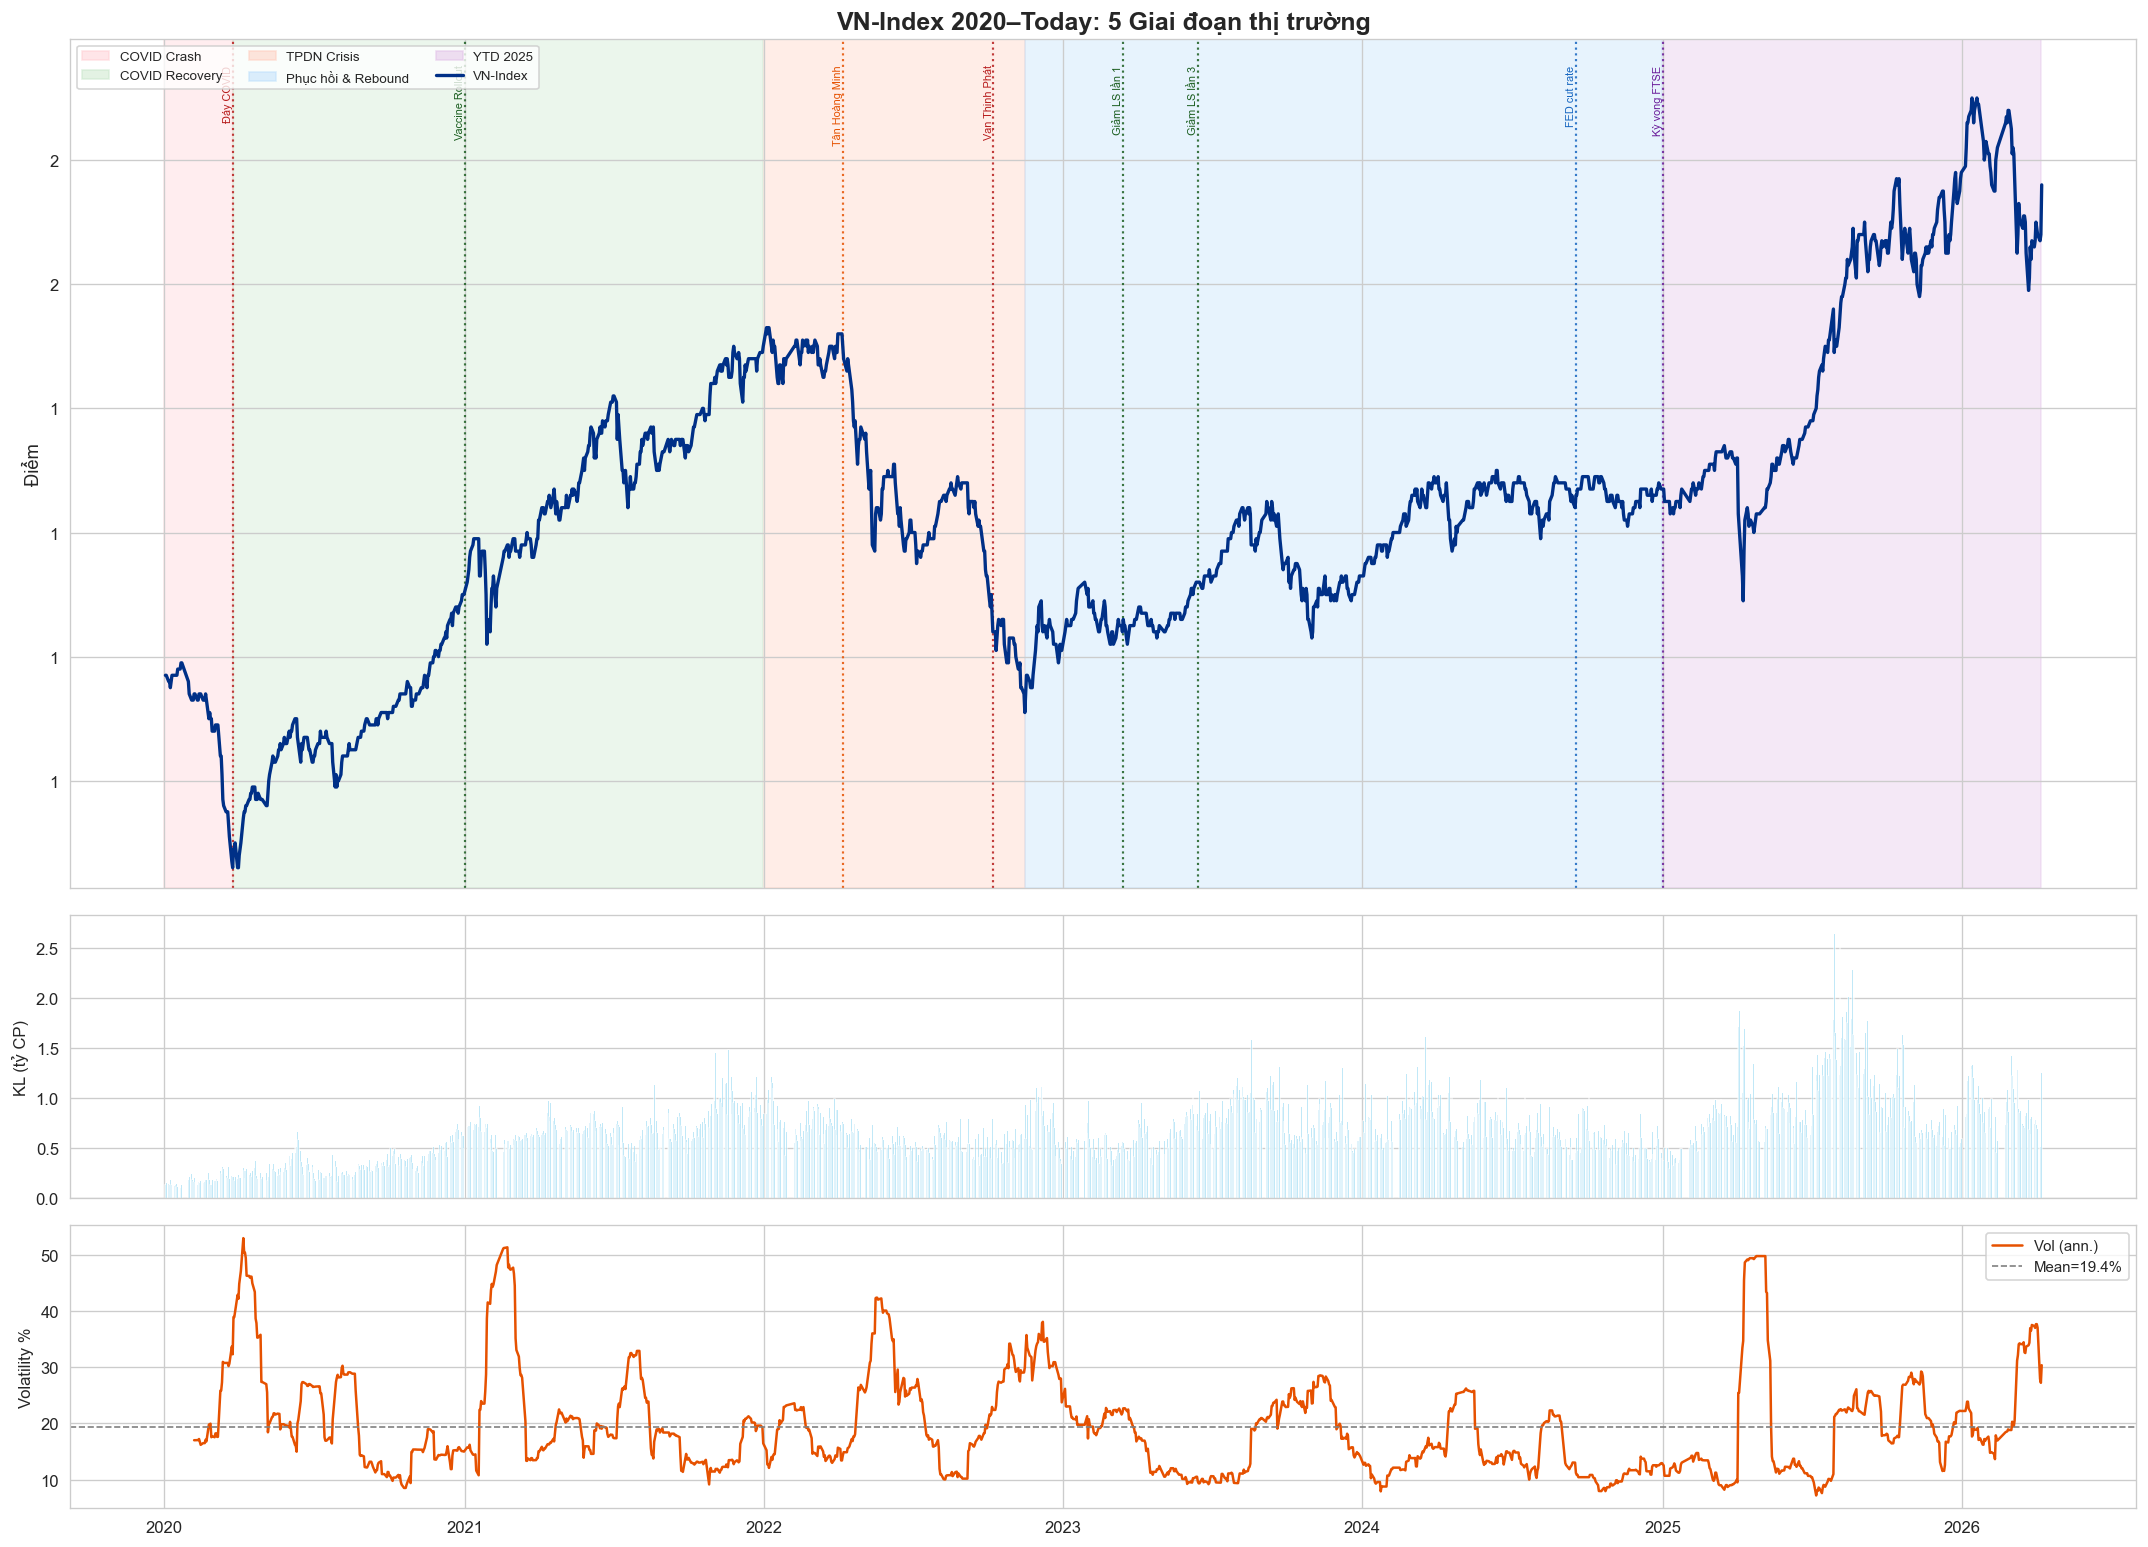

✅ 01_vnindex.png


In [7]:
# Chart 1 — VN-Index: 5 giai đoạn + sự kiện + volatility
vni = idx[idx['symbol']=='VNINDEX'].sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(18,13), sharex=True,
                          gridspec_kw={'height_ratios':[3,1,1]})
ax = axes[0]
shade_phases(ax)
ax.plot(vni['date'], vni['close'], '#003087', lw=2, zorder=3, label='VN-Index')
ax.set_ylim(vni['close'].min()*0.95, vni['close'].max()*1.05)
mark_events(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_ylabel('Điểm', fontsize=11)
ax.set_title('VN-Index 2020–Today: 5 Giai đoạn thị trường', fontsize=15, fontweight='bold')
handles = [mpatches.Patch(color=v[0], label=v[1], alpha=0.5) for v in PHASE_COLORS.values()]
handles += [plt.Line2D([0],[0], color='#003087', lw=2, label='VN-Index')]
ax.legend(handles=handles, loc='upper left', fontsize=8, ncol=3)

axes[1].bar(vni['date'], vni['volume']/1e9, color='#00A3E0', alpha=0.6, width=1)
axes[1].set_ylabel('KL (tỷ CP)', fontsize=10)

axes[2].plot(vni['date'], vni['vol_ann'], '#E65100', lw=1.5, label='Vol (ann.)')
axes[2].axhline(vni['vol_ann'].mean(), color='gray', ls='--', lw=1,
               label=f'Mean={vni["vol_ann"].mean():.1f}%')
axes[2].set_ylabel('Volatility %', fontsize=10)
axes[2].legend(fontsize=9)

plt.tight_layout()
fig.savefig(f'{ASSET}/01_vnindex.png', dpi=150, bbox_inches='tight')
plt.show() ; print('✅ 01_vnindex.png')

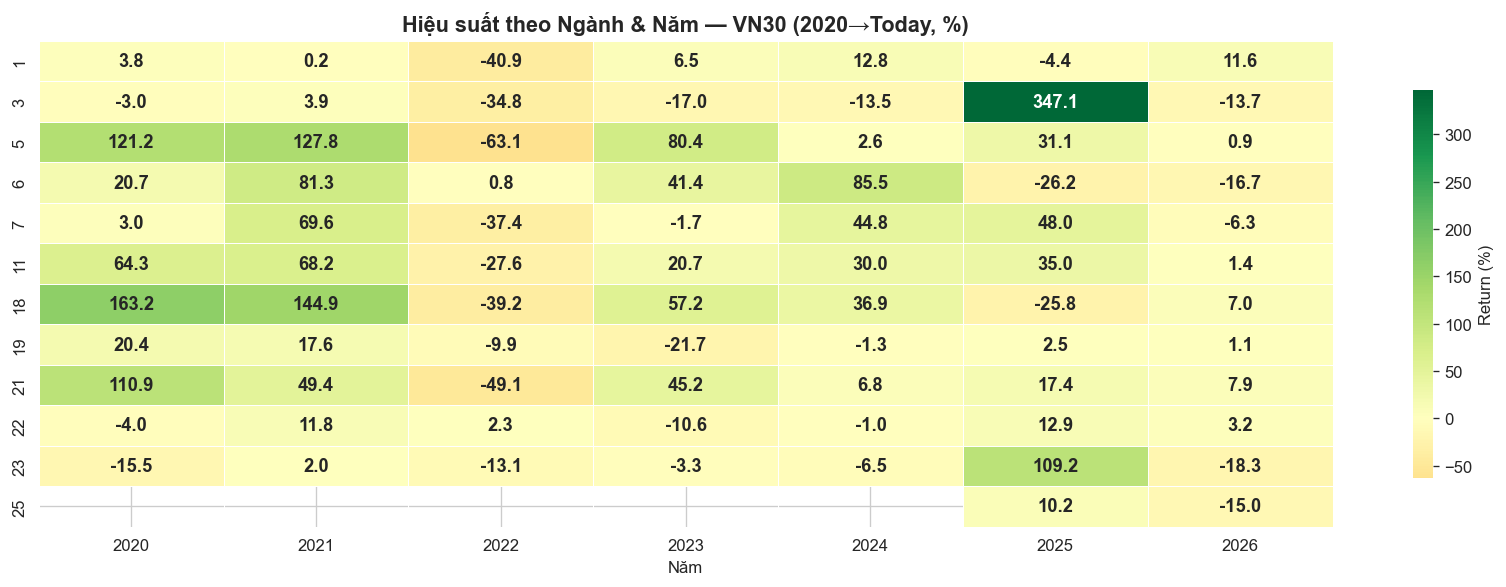

✅ 02_sector_heatmap.png


In [8]:
# Chart 2 — Sector Heatmap annual return
ann = (
    df.groupby(['ticker','sector','year'])
    .apply(lambda g: (g.sort_values('date')['close'].iloc[-1] /
                      g.sort_values('date')['close'].iloc[0] - 1) * 100)
    .reset_index(name='annual_ret')
)
pivot = ann.groupby(['sector','year'])['annual_ret'].mean().unstack()
fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size':11,'weight':'bold'},
            cbar_kws={'label':'Return (%)','shrink':0.8})
ax.set_title('Hiệu suất theo Ngành & Năm — VN30 (2020→Today, %)', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm') ; ax.set_ylabel('')
plt.tight_layout()
fig.savefig(f'{ASSET}/02_sector_heatmap.png', dpi=150, bbox_inches='tight')
plt.show() ; print('✅ 02_sector_heatmap.png')

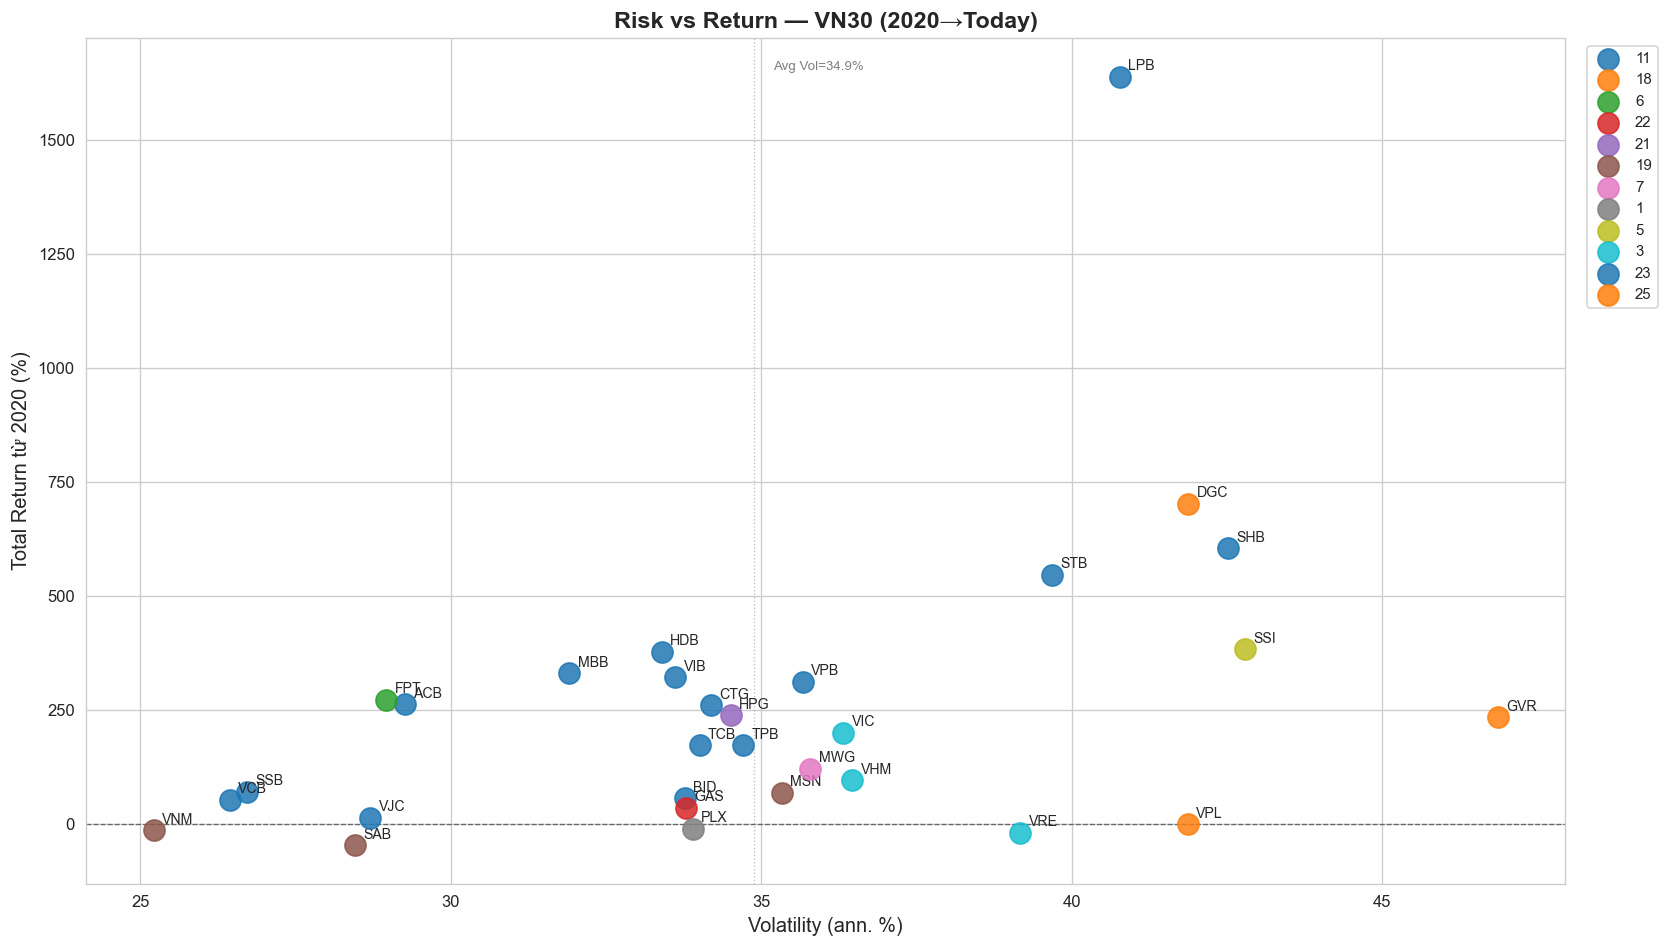

✅ 03_risk_return.png


In [9]:
# Chart 3 — Risk-Return Scatter
stats = (
    df.groupby(['ticker','sector'])
    .apply(lambda g: pd.Series({
        'total_ret' : g.sort_values('date')['cum_ret'].iloc[-1],
        'volatility': g['ret_1d'].std() * np.sqrt(252) * 100,
        'sharpe'    : (g['ret_1d'].mean()*252) / (g['ret_1d'].std()*np.sqrt(252)+1e-9),
        'max_dd'    : ((g.sort_values('date')['close'] /
                        g.sort_values('date')['close'].cummax())-1).min()*100,
        'calmar'    : (g['ret_1d'].mean()*252) / abs((g.sort_values('date')['close'] /
                       g.sort_values('date')['close'].cummax()-1).min()+1e-9),
    }))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14,8))
colors = plt.cm.tab10.colors
for i, sec in enumerate(stats['sector'].unique()):
    sub = stats[stats['sector']==sec]
    ax.scatter(sub['volatility'], sub['total_ret'], color=colors[i%10],
               s=160, alpha=0.85, label=sec, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r['ticker'], (r['volatility'], r['total_ret']),
                    fontsize=8.5, xytext=(5,4), textcoords='offset points')
avg_vol = stats['volatility'].mean()
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(avg_vol, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.text(avg_vol+0.3, ax.get_ylim()[1]*0.96, f'Avg Vol={avg_vol:.1f}%', fontsize=8, color='gray')
ax.set_xlabel('Volatility (ann. %)', fontsize=12)
ax.set_ylabel('Total Return từ 2020 (%)', fontsize=12)
ax.set_title('Risk vs Return — VN30 (2020→Today)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
fig.savefig(f'{ASSET}/03_risk_return.png', dpi=150, bbox_inches='tight')
plt.show() ; print('✅ 03_risk_return.png')

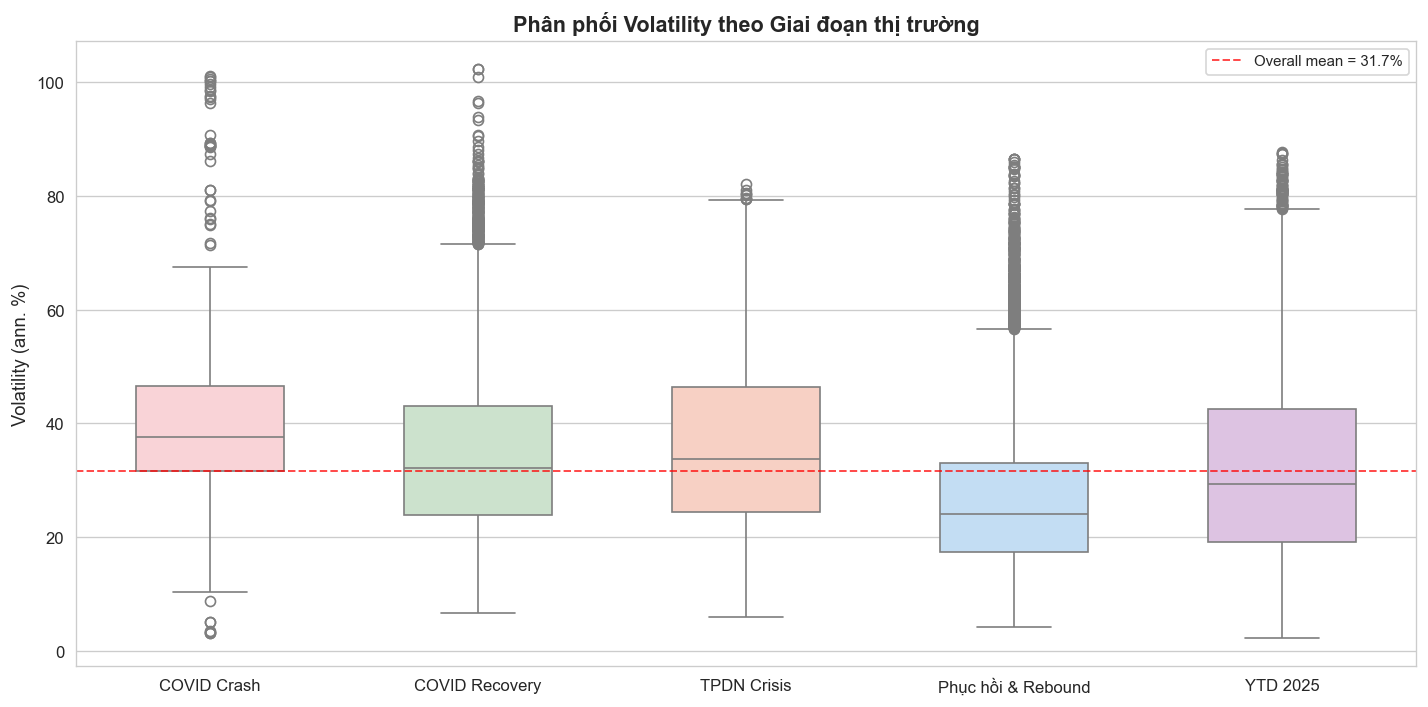

✅ 04_volatility_regime.png


In [10]:
# Chart 4 — Volatility regime per phase
vol_phase = df[df['vol_ann'].notna()][['phase','vol_ann']].copy()
phase_order = list(PHASE_COLORS.keys())
phase_lbls  = [PHASE_COLORS[p][1] for p in phase_order]
lbl_map     = {p: PHASE_COLORS[p][1] for p in phase_order}
col_map     = {PHASE_COLORS[p][1]: PHASE_COLORS[p][0] for p in phase_order}
vol_phase['phase_lbl'] = vol_phase['phase'].map(lbl_map)
present_lbls = [l for l in phase_lbls if l in vol_phase['phase_lbl'].unique()]

fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=vol_phase, x='phase_lbl', y='vol_ann', order=present_lbls,
            palette=[col_map[l] for l in present_lbls], width=0.55, ax=ax)
ax.axhline(vol_phase['vol_ann'].mean(), color='red', ls='--', lw=1.2, alpha=0.7,
           label=f'Overall mean = {vol_phase["vol_ann"].mean():.1f}%')
ax.set_title('Phân phối Volatility theo Giai đoạn thị trường', fontsize=13, fontweight='bold')
ax.set_xlabel('') ; ax.set_ylabel('Volatility (ann. %)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{ASSET}/04_volatility_regime.png', dpi=150, bbox_inches='tight')
plt.show() ; print('✅ 04_volatility_regime.png')

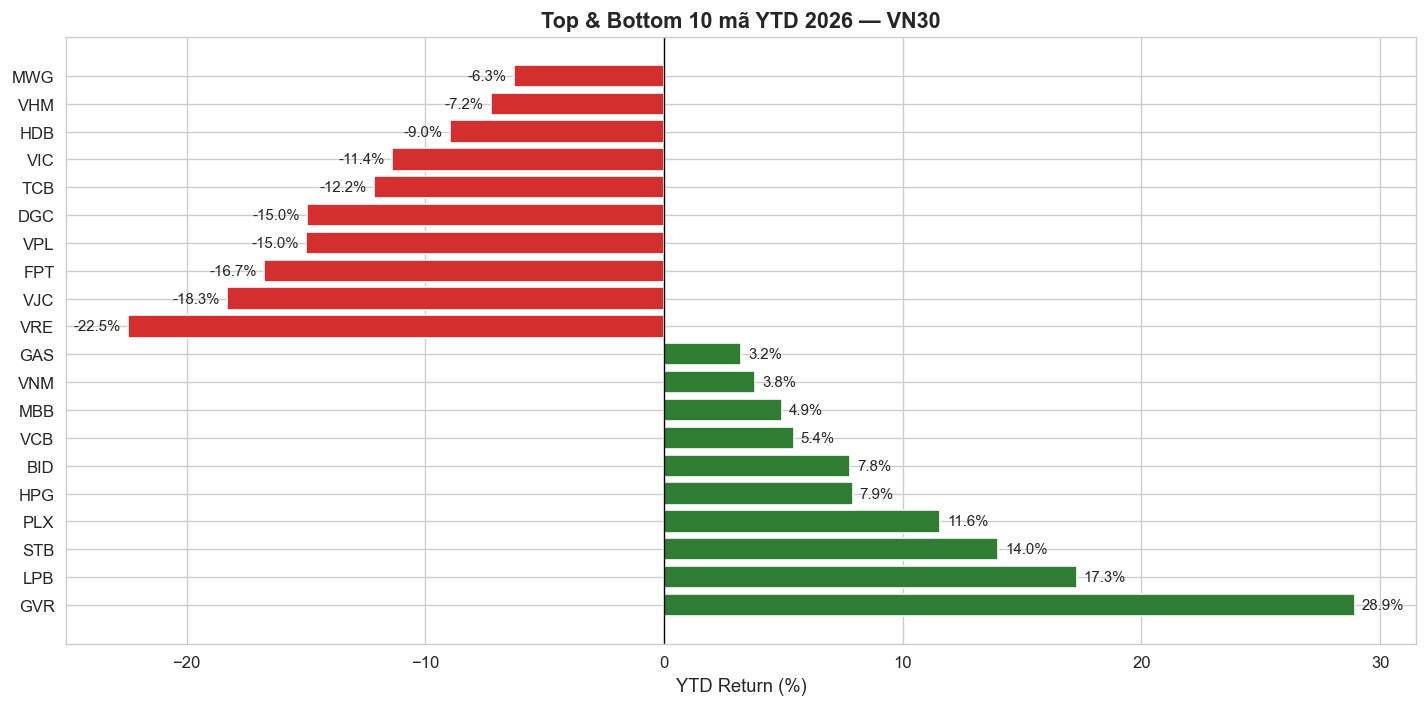

✅ 05_ytd_momentum.png


In [11]:
# Chart 5 — YTD Momentum bar chart
latest = df.sort_values('date').groupby('ticker').last().reset_index()
latest['sector'] = latest['ticker'].map(SECTOR).fillna('Khác')
top10  = latest.nlargest(10,  'ytd_ret')[['ticker','ytd_ret','sector']]
bot10  = latest.nsmallest(10, 'ytd_ret')[['ticker','ytd_ret','sector']]
bar_df = pd.concat([top10, bot10]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12,6))
bar_colors = ['#2E7D32' if x>=0 else '#D32F2F' for x in bar_df['ytd_ret']]
bars = ax.barh(bar_df['ticker'], bar_df['ytd_ret'], color=bar_colors, edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w+(0.3 if w>=0 else -0.3), bar.get_y()+bar.get_height()/2,
            f'{w:.1f}%', va='center', ha='left' if w>=0 else 'right', fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('YTD Return (%)', fontsize=11)
ax.set_title(f'Top & Bottom 10 mã YTD {date.today().year} — VN30', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{ASSET}/05_ytd_momentum.png', dpi=150, bbox_inches='tight')
plt.show() ; print('✅ 05_ytd_momentum.png')

## 6 · Summary stats & Export CSV

In [12]:
summary = (
    df.groupby(['ticker','sector'])
    .apply(lambda g: pd.Series({
        'total_ret'      : g.sort_values('date')['cum_ret'].iloc[-1],
        'volatility'     : g['ret_1d'].std() * np.sqrt(252) * 100,
        'sharpe'         : (g['ret_1d'].mean()*252)/(g['ret_1d'].std()*np.sqrt(252)+1e-9),
        'max_dd'         : ((g.sort_values('date')['close']/g.sort_values('date')['close'].cummax())-1).min()*100,
        'calmar'         : (g['ret_1d'].mean()*252)/abs((g.sort_values('date')['close']/g.sort_values('date')['close'].cummax()-1).min()+1e-9),
        'latest_close'   : g.sort_values('date')['close'].iloc[-1],
        'latest_rsi'     : g.sort_values('date')['rsi'].iloc[-1],
        'latest_ytd'     : g.sort_values('date')['ytd_ret'].iloc[-1],
        'latest_ret_3m'  : g.sort_values('date')['ret_3m'].iloc[-1],
        'latest_vol'     : g.sort_values('date')['vol_ann'].iloc[-1],
        'data_from'      : g['date'].min().strftime('%Y-%m-%d'),
        'data_to'        : g['date'].max().strftime('%Y-%m-%d'),
        'n_days'         : len(g),
    }))
    .reset_index().round(4)
)

phase_perf = (
    df.groupby(['ticker','sector','phase'])
    .apply(lambda g: (g.sort_values('date')['close'].iloc[-1]/g.sort_values('date')['close'].iloc[0]-1)*100)
    .reset_index(name='phase_ret')
)

def save(d, name, note=''):
    p = f'{DATA}/{name}'
    d.to_csv(p, index=False, encoding='utf-8-sig')
    print(f'  ✅ {name:<38s} {len(d):>8,} rows  {note}')

KEEP = ['ticker','sector','phase','date','year','quarter','month','week',
        'open','high','low','close','volume',
        'ret_1d','ret_1w','ret_1m','ret_3m','ret_6m','ret_1y','cum_ret','ytd_ret',
        'ma_20','ma_50','ma_200','bb_up','bb_lo','bb_pct',
        'rsi','macd','macd_sig','macd_hist','vol_ann','vol_ratio']

print('💾 Xuất CSV...\n')
save(df[[c for c in KEEP if c in df.columns]], 'price_history.csv', '← Power BI: Price, Sector, Phase')
save(idx, 'market_index.csv',       '← Power BI: Market Overview')
save(summary, 'summary_stats.csv',  '← Power BI: Screener, Risk')
save(phase_perf, 'phase_perf.csv',  '← Power BI: Phase Analysis')

print(f'\n🎉 Xong! {DATA}/ | đến {df["date"].max().date()}')

💾 Xuất CSV...

  ✅ price_history.csv                        45,185 rows  ← Power BI: Price, Sector, Phase
  ✅ market_index.csv                          4,686 rows  ← Power BI: Market Overview
  ✅ summary_stats.csv                            30 rows  ← Power BI: Screener, Risk
  ✅ phase_perf.csv                              145 rows  ← Power BI: Phase Analysis

🎉 Xong! data/ | đến 2026-04-08


In [15]:
print(f'\n📊 VN30 Summary (2020 → {df["date"].max().date()})\n')
disp = summary[['ticker','sector','total_ret','volatility','sharpe','max_dd','calmar','latest_ytd','latest_rsi']]\
       .sort_values('sharpe', ascending=False)\
       .rename(columns={'total_ret':'Total%','volatility':'Vol%','sharpe':'Sharpe',
                        'max_dd':'MaxDD%','calmar':'Calmar','latest_ytd':'YTD%','latest_rsi':'RSI'})
print(disp.to_string(index=False))


📊 VN30 Summary (2020 → 2026-04-08)

ticker  sector    Total%   Vol%  Sharpe  MaxDD%  Calmar    YTD%    RSI
   LPB      11 1,639.927 40.773   1.343 -65.804   0.832  17.284 65.385
   DGC      18   702.594 41.878   1.016 -62.581   0.680 -14.962 43.522
   STB      11   547.059 39.686   0.958 -58.577   0.649  13.990 57.738
   SHB      11   605.069 42.514   0.955 -66.287   0.613  -3.652 56.477
   HDB      11   378.221 33.397   0.924 -47.731   0.646  -8.981 56.604
   MBB      11   331.118 31.910   0.900 -50.645   0.567   4.931 51.667
   FPT       6   273.466 28.956   0.879 -44.499   0.572 -16.737 55.157
   VIB      11   322.141 33.614   0.863 -56.635   0.512  -1.977 57.971
   ACB      11   262.952 29.254   0.860 -42.416   0.593   0.417 55.208
   VPB      11   311.940 35.671   0.820 -45.504   0.642  -1.075 61.765
   SSI       5   383.553 42.787   0.809 -72.499   0.477   0.858 62.632
   CTG      11   260.406 34.184   0.777 -51.880   0.512   0.000 54.595
   HPG      21   238.573 34.503   0.743 